# EasyMagpieTTS — vLLM-Omni inference demo

End-to-end inference through `easymagpie_vllm_omni` on a checkpoint converted by
`easy_magpietts_convert_to_vllm.py`: prefill (speaker embedding + context text) ->
autoregressive decode (target text, one subword per step) -> stacked audio codes ->
vocode to waveform.

Run inside the `vllm_omni_env` with the plugin installed
(`pip install -e examples/tts/easymagpie_vllm_omni`).

In [1]:
import os

os.environ.setdefault("VLLM_WORKER_MULTIPROC_METHOD", "spawn")

import json
import tempfile
import uuid
from pathlib import Path

import torch
import yaml

from vllm import SamplingParams
from vllm.sampling_params import RequestOutputKind
from vllm_omni import AsyncOmni

from easymagpie_vllm_omni.config import EasyMagpieOmniArch

print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

/home/vklimkov/miniconda3/envs/emp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`


torch: 2.11.0+cu130 | cuda: True


## 1. Converted model directory

`MODEL_DIR` is the directory written by the converter: `config.json`, weights, the
text tokenizer, and per-speaker embeddings. The engine loads everything from it;
here we only read a few config scalars used to build the prompt.

In [2]:
MODEL_DIR = Path("/home/vklimkov/workspace/emp/NeMo/examples/tts/easymagpie_vllm_omni/easymp_vllm_model")
assert (MODEL_DIR / "config.json").exists(), f"No config.json under {MODEL_DIR}; run the converter first."

config = json.loads((MODEL_DIR / "config.json").read_text())
arch = EasyMagpieOmniArch.from_hf_config(type("Cfg", (), config))

TEXT_VOCAB = int(config["text_vocab_size"])
TEXT_EOS_ID = TEXT_VOCAB - 2
AUDIO_STOP_TOKEN_ID = max(1, int(config.get("vocab_size", 2)) - 1)
SPEECH_DELAY = int(getattr(arch, "streaming_speech_delay", 0) or 0)

print(f"Model dir                : {MODEL_DIR}")
print(f"num_stacked_codebooks    : {arch.num_stacked_codebooks}  (C*S)")
print(f"audio_bos / audio_eos id : {arch.audio_bos_id} / {arch.audio_eos_id}")
print(f"text_vocab / text_eos    : {TEXT_VOCAB} / {TEXT_EOS_ID}")
print(f"audio-EOS stop token id  : {AUDIO_STOP_TOKEN_ID}")
print(f"streaming speech delay   : {SPEECH_DELAY} frames")

Model dir                : /home/vklimkov/workspace/emp/NeMo/examples/tts/easymagpie_vllm_omni/easymp_vllm_model
num_stacked_codebooks    : 16  (C*S)
audio_bos / audio_eos id : 1024 / 1025
text_vocab / text_eos    : 131075 / 131073
audio-EOS stop token id  : 1
streaming speech delay   : 5 frames


## 2. Single-stage `AsyncOmni` engine

One `llm` stage running the EasyMagpie talker (`worker_type="ar"`).
`final_output_type="audio"` makes the runner attach the per-step `audio_codes`
payload to each output. `async_chunk=True` lets the streaming-text path (§5) feed
one subword per step and is a no-op for the whole-text path (§4), so a single
engine serves both.

In [3]:
DECODE_STEPS = 256       # max audio frames to decode (trimmed at audio EOS)
MAX_MODEL_LEN = 1024
MAX_NUM_BATCHED_TOKENS = 1024

stage_cfg = {
    "async_chunk": True,
    "stage_args": [
        {
            "stage_id": 0,
            "stage_type": "llm",
            "is_comprehension": True,
            "final_output": True,
            "final_output_type": "audio",
            "runtime": {"devices": "0"},
            "engine_args": {
                "model_stage": "easymagpie",
                "max_num_seqs": 1,
                "model_arch": "EasyMagpieTTSForConditionalGeneration",
                "worker_type": "ar",
                "scheduler_cls": "easymagpie_vllm_omni.scheduler.EasyMagpieARAsyncScheduler",
                "trust_remote_code": True,
                "async_scheduling": True,
                "enable_prefix_caching": False,
                "enforce_eager": False,
                "engine_output_type": "audio",
                "gpu_memory_utilization": 0.8,
                "distributed_executor_backend": "uni",
                "max_num_batched_tokens": MAX_NUM_BATCHED_TOKENS,
                "max_model_len": MAX_MODEL_LEN,
                "dtype": "float16",
                "mamba_ssm_cache_dtype": "float32",
                "attention_backend": "TRITON_ATTN",
                "skip_tokenizer_init": True,
            },
            "default_sampling_params": {
                "temperature": 0.0,
                "max_tokens": DECODE_STEPS,
                "detokenize": False,
                "ignore_eos": True,
                "stop_token_ids": [AUDIO_STOP_TOKEN_ID],
            },
        }
    ],
}

_tmp = tempfile.NamedTemporaryFile(
    mode="w", suffix=".yaml", prefix="easymagpie_omni_demo_", delete=False,
)
yaml.dump(stage_cfg, _tmp, sort_keys=False)
_tmp.close()
STAGE_CFG_PATH = _tmp.name
print(f"Stage config: {STAGE_CFG_PATH}")

omni = AsyncOmni(
    model=str(MODEL_DIR),
    stage_configs_path=STAGE_CFG_PATH,
    log_stats=False,
    stage_init_timeout=300,
)
print("Engine ready (single stage: EasyMagpie talker)")

Stage config: /tmp/easymagpie_omni_demo_6qki61d4.yaml
INFO 06-15 18:51:09 [omni_base.py:172] [AsyncOmni] Initializing with model /home/vklimkov/workspace/emp/NeMo/examples/tts/easymagpie_vllm_omni/easymp_vllm_model
INFO 06-15 18:51:09 [async_omni_engine.py:269] [AsyncOmniEngine] Initializing with model /home/vklimkov/workspace/emp/NeMo/examples/tts/easymagpie_vllm_omni/easymp_vllm_model
WARNING 06-15 18:51:09 [utils.py:597] --stage-configs-path is deprecated; migrate '/tmp/easymagpie_omni_demo_6qki61d4.yaml' and use --deploy-config.
INFO 06-15 18:51:09 [async_omni_engine.py:331] [AsyncOmniEngine] Launching Orchestrator thread with 1 stages
INFO 06-15 18:51:09 [initialization.py:352] Loaded OmniTransferConfig with 0 connector configurations


OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.
No exporters were provided. This means that no telemetry data will be collected.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 1), got 2. This may result in unexpected behavior.
[transformers] Model config: forced_mask_token_id must be `None` or an integer within the vocabulary (between 0 and 1), got 1028. This may result in unexpected behavior.


INFO 06-15 18:51:18 [model.py:568] Resolved architecture: EasyMagpieTTSForConditionalGeneration
INFO 06-15 18:51:18 [model.py:2032] Downcasting torch.float32 to torch.float16.
INFO 06-15 18:51:18 [model.py:1697] Using max model len 1024


2026-06-15 18:51:19,006	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 06-15 18:51:19 [scheduler.py:239] Chunked prefill is enabled with max_num_batched_tokens=1024.
INFO 06-15 18:51:19 [vllm.py:886] Asynchronous scheduling is enabled.
INFO 06-15 18:51:19 [kernel.py:212] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
INFO 06-15 18:51:19 [stage_init_utils.py:535] [stage_init] Stage-0 set runtime devices: 0
INFO 06-15 18:51:19 [async_omni_engine.py:706] [AsyncOmniEngine] Stage 0 engine launch started


...

(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:25 [parallel_state.py:1410] world_size=1 rank=0 local_rank=0 distributed_init_method=tcp://10.221.143.184:50843 backend=nccl
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:25 [parallel_state.py:1723] rank 0 in world size 1 is assigned as DP rank 0, PP rank 0, PCP rank 0, TP rank 0, EP rank 0, EPLB rank N/A
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:26 [topk_topp_sampler.py:45] Using FlashInfer for top-p & top-k sampling.
(StageEngineCoreProc pid=2884868) WARNING 06-15 18:51:26 [base.py:188] [LLM Worker 0] Sleep Mode DISABLED.
(StageEngineCoreProc pid=2884868) WARNING 06-15 18:51:26 [base.py:188] [LLM Worker 0] Sleep Mode DISABLED.
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:26 [gpu_model_runner.py:4857] Starting to load model /home/vklimkov/workspace/emp/NeMo/examples/tts/easymagpie_vllm_omni/easymp_vllm_model...
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:26 [unquantized.py:288] Using TRITON Unquantized MoE b

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  2.15it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00,  2.14it/s]
(StageEngineCoreProc pid=2884868) 


(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:31 [default_loader.py:397] Loading weights took 5.17 seconds
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:31 [unquantized.py:345] Using MoEPrepareAndFinalizeNoDPEPModular
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:32 [gpu_model_runner.py:4959] Model loading took 2.62 GiB memory and 5.229138 seconds
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:32 [interface.py:645] Setting attention block size to 400 tokens to ensure that attention page size is >= mamba page size.
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:32 [interface.py:669] Padding mamba page size by 1.39% to ensure that mamba page size and attention page size are exactly equal.
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:33 [backends.py:1089] Using cache directory: /home/vklimkov/.cache/vllm/torch_compile_cache/44b29fc96b/rank_0_0/backbone for vLLM's torch.compile
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:33 [backends.py:1148] Dynamo byte

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 2/2 [00:00<00:00,  7.03it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 1/1 [00:00<00:00, 18.54it/s]


(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:38 [gpu_model_runner.py:6243] Graph capturing finished in 1 secs, took 0.07 GiB
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:38 [jit_monitor.py:54] Kernel JIT monitor activated — Triton JIT compilations during inference will be logged as warnings.
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:38 [core.py:299] init engine (profile, create kv cache, warmup model) took 5.53 s (compilation: 1.41 s)
(StageEngineCoreProc pid=2884868) WARNING 06-15 18:51:38 [scheduler.py:181] Using custom scheduler class easymagpie_vllm_omni.scheduler.EasyMagpieARAsyncScheduler. This scheduler interface is not public and compatibility may not be maintained.
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:38 [factory.py:46] Created connector: SharedMemoryConnector
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:38 [vllm.py:886] Asynchronous scheduling is enabled.
(StageEngineCoreProc pid=2884868) INFO 06-15 18:51:38 [kernel.py:212] Final IR op

## 3. Build the prompt

Per-request inputs passed via `additional_information`: `speaker_embedding`
`(T_audio, embedding_dim)`, the `context_text` string, and the target `text` (all
tokenized in-engine). `prompt_token_ids` are placeholders sized by
`estimate_prompt_len(...)` to match the assembled prefill context. Audio sampling
`temperature` / `top_k` are forwarded to the local transformer.

In [4]:
torch.manual_seed(0)

from transformers import AutoTokenizer

from easymagpie_vllm_omni.easymagpie import EasyMagpieTTSForConditionalGeneration

SPEAKER_NAME = "eng"
_loaded = torch.load(MODEL_DIR / "speaker_embeddings" / f"{SPEAKER_NAME}.pt", map_location="cpu")
speaker_embedding = _loaded["speaker_encoding"] if isinstance(_loaded, dict) else _loaded
speaker_embedding = speaker_embedding.to(torch.float32)

CONTEXT_TEXT = "[EN]"
TEXT = "Hello, this is a test of the EasyMagpie text to speech model."

# Audio sampling (local transformer); temperature=0 == argmax (deterministic).
LT_TEMPERATURE = 0.0
LT_TOPK = 80

# Same tokenizer the engine loads from MODEL_DIR; used only to size the placeholders.
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, trust_remote_code=True)
prompt_len = EasyMagpieTTSForConditionalGeneration.estimate_prompt_len(
    speaker_embedding,
    tokenize=lambda t: tokenizer.encode(t),
    context_text=CONTEXT_TEXT,
    has_task_embedding=arch.num_task_embeddings > 0,
)

prompt = {
    "prompt_token_ids": [0] * prompt_len,
    "additional_information": {
        "speaker_embedding": speaker_embedding,
        "context_text": CONTEXT_TEXT,
        "text": TEXT,
        "temperature": LT_TEMPERATURE,
        "top_k": LT_TOPK,
    },
}
assert prompt_len + DECODE_STEPS <= MAX_MODEL_LEN

# output_kind=DELTA: audio_codes arrives as a growing list during decode
# ([prefill_prefix, frame_0, frame_1, ...]); prefill/final steps yield a tensor.
sampling_params = SamplingParams(
    temperature=0.0,
    max_tokens=DECODE_STEPS,
    detokenize=False,
    ignore_eos=True,
    stop_token_ids=[AUDIO_STOP_TOKEN_ID],
    output_kind=RequestOutputKind.DELTA,
)

print(f"speaker_embedding         : {tuple(speaker_embedding.shape)}")
print(f"context_text / text       : {CONTEXT_TEXT!r} / {TEXT!r}")
print(f"prompt_len (placeholders) : {prompt_len}")

[transformers] The tokenizer you are loading from '/home/vklimkov/workspace/emp/NeMo/examples/tts/easymagpie_vllm_omni/easymp_vllm_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


speaker_embedding         : (64, 1536)
context_text / text       : '[EN]' / 'Hello, this is a test of the EasyMagpie text to speech model.'
prompt_len (placeholders) : 67


## 4. Whole-text inference -> audio codes

`omni.generate(...)` yields one `RequestOutput` per engine step, each carrying the
**cumulative** `multimodal_output["audio_codes"]` tensor: the first `prompt_len`
rows are the prefill prefix, followed by one `(1, C*S)` decoded frame per step
(occasionally surfaced as a list of per-step tensors, which we just concatenate).
We keep the largest tensor seen, drop the prefill prefix, then drop the
`speech_delay` warm-up frames and the trailing audio-EOS frame.

In [5]:
async def run_request(prompt, sampling_params):
    """Keep the cumulative audio-code tensor [prefill_prefix | decoded frames].

    Each step exposes audio_codes as a growing tensor (sometimes a list of per-step
    tensors, which we concatenate); we keep the largest one seen.
    """
    request_id = f"easymagpie-{uuid.uuid4().hex[:8]}"
    codes = None
    async for out in omni.generate(prompt, sampling_params_list=[sampling_params], request_id=request_id):
        payload = (out.multimodal_output or {}).get("audio_codes")
        if isinstance(payload, list):
            payload = torch.cat([t for t in payload if isinstance(t, torch.Tensor)], dim=0) if payload else None
        if isinstance(payload, torch.Tensor) and (codes is None or payload.shape[0] >= codes.shape[0]):
            codes = payload.detach().cpu().to(torch.long)
    return codes


codes = await run_request(prompt, sampling_params)
# Rows 0:prompt_len are the prefill prefix; decoded frames follow. Drop the prefix,
# the speech-delay warm-up frames, and the trailing audio-EOS frame.
audio_codes = codes[prompt_len + SPEECH_DELAY : -1]
print(f"cumulative codes : {tuple(codes.shape)}  (prompt_len={prompt_len})")
print(f"audio_codes      : {tuple(audio_codes.shape)}  (dropped prefix + {SPEECH_DELAY} warm-up + 1 EOS)")

WARNING 06-15 18:51:39 [input_processor.py:274] Passing raw prompts to InputProcessor is deprecated and will be removed in v0.18. You should instead pass the outputs of Renderer.render_cmpl() or Renderer.render_chat().
WARNING 06-15 18:51:39 [base.py:301] Using None for EOS token id because tokenizer is not initialized
INFO 06-15 18:51:39 [stage_engine_core_client.py:265] [StageEngineCoreClient] stage-0 [rep-0] add request: easymagpie-2fc385b4


(StageEngineCoreProc pid=2884868) [transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 1), got 2. This may result in unexpected behavior.
(StageEngineCoreProc pid=2884868) [transformers] Model config: forced_mask_token_id must be `None` or an integer within the vocabulary (between 0 and 1), got 1028. This may result in unexpected behavior.


(StageEngineCoreProc pid=2884868) WARNING 06-15 18:51:39 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _zero_kv_blocks_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(StageEngineCoreProc pid=2884868) WARNING 06-15 18:51:39 [gpu_model_runner.py:408] additional_information on request data is deprecated, use model_intermediate_buffer
(StageEngineCoreProc pid=2884868) WARNING 06-15 18:51:39 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _compute_slot_mapping_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


(StageEngineCoreProc pid=2884868) [transformers] The tokenizer you are loading from '/home/vklimkov/workspace/emp/NeMo/examples/tts/easymagpie_vllm_omni/easymp_vllm_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


(StageEngineCoreProc pid=2884868) WARNING 06-15 18:51:40 [gpu_model_runner.py:1595] _merge_additional_information_update is deprecated, use _update_intermediate_buffer
(StageEngineCoreProc pid=2884868) WARNING 06-15 18:51:40 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _causal_conv1d_fwd_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(StageEngineCoreProc pid=2884868) WARNING 06-15 18:51:40 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _chunk_cumsum_fwd_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(StageEngineCoreProc pid=2884868) WARNING 06-15 18:51:40 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _chunk_state_fwd_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(StageEngineCoreProc pid=2884868) WARNING 06-15 18:51:40 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _

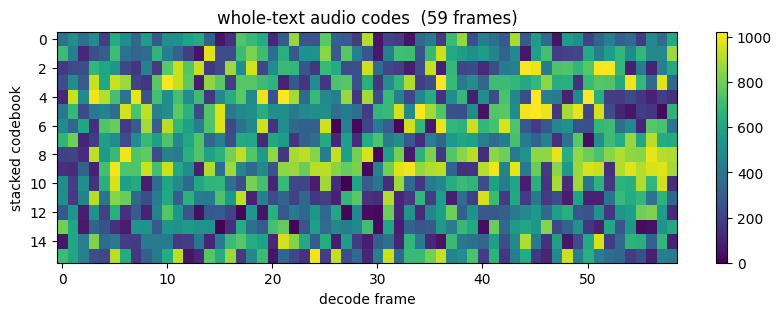

In [6]:
import matplotlib.pylab as plt

plt.figure(figsize=(10, 3))
plt.imshow(audio_codes.T, aspect="auto", interpolation="nearest")
plt.title(f"whole-text audio codes  ({audio_codes.shape[0]} frames)")
plt.xlabel("decode frame")
plt.ylabel("stacked codebook")
plt.colorbar()
plt.show()

## 5. Streaming text input (chunked subword feed)

Same model, but push subword ids as a live caller would — **several at a time**, in
**one `StreamingInput` per chunk** (fewer ZMQ round-trips).

The model is fundamentally **one text subword per decode frame**: every step adds
exactly one `text_token` embedding to the backbone, so it can't *consume* N tokens
in a single frame. But the caller doesn't need to send one `StreamingInput` per
frame: it sends a chunk of N ids in a single `StreamingInput` with `max_tokens=N`,
and the engine **free-runs N frames** off that one chunk (exactly like the tail
chunk free-runs the acoustic tail). The model appends the chunk's ids to a
persistent `text_tokens` buffer and consumes one per frame, indexed by
`decode_offset`.

Two rules make this exact:

* `text_token` is always a **`list[int]`** (a single id is just `[id]`; an empty
  list `[]` adds nothing — used for the tail).
* each chunk's **`max_tokens` equals the number of ids it carries**, so the segment
  stops exactly when the buffer is consumed and the next chunk's ids are appended
  exactly once.

`prompt_token_ids` stays `[0]` for every decode chunk — its length is **not** the
token count (a length > 1 would be read as a prefill). A `produce_text_chunks`
coroutine emits `TEXT_TOKENS_PER_CHUNK` ids per round into `token_q`; set it to
`1`, `3`, `5`, … — the audio is identical, only the number of round-trips changes.
After the text is exhausted we feed an empty chunk (`text_token=[]`) with a large
`max_tokens` until the model emits the audio-EOS token. Codes are collected exactly
as in §4 (keep the cumulative tensor, slice off prefix + warm-up + EOS).

In [ ]:
import asyncio
from collections.abc import AsyncGenerator

try:
    from vllm.engine.protocol import StreamingInput
except ImportError:
    from vllm.v1.engine.async_llm import StreamingInput

# Tokenize the target text the same way the model does (specials off + text-EOS).
text_ids = list(tokenizer.encode(TEXT, add_special_tokens=False)) + [TEXT_EOS_ID]
print(f"streamed text ids ({len(text_ids)}): {text_ids}")

# ── Chunked delivery ──────────────────────────────────────────────────────────
# A live caller emits several tokens at once. We send each chunk in ONE
# StreamingInput with max_tokens == chunk length, so the engine free-runs that many
# frames off a single message (fewer ZMQ round-trips). The model consumes one id per
# frame internally. Set to 1, 3, 5, ... — the audio is identical; only the number of
# round-trips changes. Mirrors benchmark_streaming_service.py --tokens-per-chunk.
TEXT_TOKENS_PER_CHUNK = 3
PRODUCER_DELAY_S = 0.0  # sleep between chunks to mimic a slow upstream producer
text_chunks = [text_ids[i : i + TEXT_TOKENS_PER_CHUNK] for i in range(0, len(text_ids), TEXT_TOKENS_PER_CHUNK)]
print(f"delivering {len(text_chunks)} chunk(s) of <= {TEXT_TOKENS_PER_CHUNK} token(s): {text_chunks}")


def make_stream_params(max_tokens: int) -> SamplingParams:
    """Audio-decode params for a streaming segment that emits `max_tokens` frames."""
    return SamplingParams(
        temperature=0.0,
        max_tokens=max_tokens,
        detokenize=False,
        ignore_eos=True,
        stop_token_ids=[AUDIO_STOP_TOKEN_ID],
        output_kind=RequestOutputKind.DELTA,
    )


prefill_params = make_stream_params(1)  # default for omni.generate + the prefill segment
streaming_params = make_stream_params(TEXT_TOKENS_PER_CHUNK)
TAIL_MAX_TOKENS = DECODE_STEPS - len(text_ids)
tail_params = make_stream_params(TAIL_MAX_TOKENS)

go_queue: asyncio.Queue[bool] = asyncio.Queue()
_STREAM_END = object()  # sentinel: producer is done sending text


async def produce_text_chunks(token_q: asyncio.Queue) -> None:
    """Simulate an upstream producer emitting TEXT_TOKENS_PER_CHUNK ids per round."""
    for chunk in text_chunks:
        if PRODUCER_DELAY_S:
            await asyncio.sleep(PRODUCER_DELAY_S)
        await token_q.put(chunk)
    await token_q.put(_STREAM_END)


async def stream_text_inputs(token_q: asyncio.Queue) -> AsyncGenerator[StreamingInput, None]:
    # Prefill: speaker + context, NO text (its absence selects streaming-text mode).
    # The first subword rides on the first decode chunk, not the prefill.
    prefill_info = {
        "speaker_embedding": speaker_embedding,
        "context_text": CONTEXT_TEXT,
        "temperature": LT_TEMPERATURE,
        "top_k": LT_TOPK,
    }
    yield StreamingInput(
        prompt={"prompt_token_ids": [0] * prompt_len, "additional_information": prefill_info},
        sampling_params=prefill_params,  # max_tokens=1 -> the prefill segment emits 1 frame
    )

    # One StreamingInput per chunk: `text_token` is the whole chunk (a list[int]) and
    # `max_tokens == len(chunk)`, so the engine free-runs that many frames off the one
    # message. We release the next chunk only after the previous segment's frames are
    # done (one `go_queue` token per output frame), so the chunk's ids are appended to
    # the model's buffer before the next chunk replaces `text_token`. `prev_frames`
    # tracks how many frames the last-yielded segment will emit (prefill -> 1).
    prev_frames = 1
    ended = False
    chunks: list[list[int]] = []
    while True:
        while not chunks and not ended:
            item = await token_q.get()
            if item is _STREAM_END:
                ended = True
            else:
                chunks.append([int(t) for t in item])
        if not chunks:
            break
        chunk = chunks.pop(0)
        for _ in range(prev_frames):
            await go_queue.get()
        params = streaming_params if len(chunk) == TEXT_TOKENS_PER_CHUNK else make_stream_params(len(chunk))
        yield StreamingInput(
            prompt={"prompt_token_ids": [0], "additional_information": {"text_token": chunk}},
            sampling_params=params,
        )
        prev_frames = len(chunk)

    # Tail: an empty chunk (`text_token=[]`) masks the text channel; the large
    # `max_tokens` lets the engine free-run the acoustic tail to audio-EOS.
    for _ in range(prev_frames):
        await go_queue.get()
    yield StreamingInput(
        prompt={"prompt_token_ids": [0], "additional_information": {"text_token": []}},
        sampling_params=tail_params,
    )
    # Generator ends here: the engine now decodes the acoustic tail uninterrupted
    # on `tail_params.max_tokens` (honored thanks to the max_tokens propagation in
    # EasyMagpieARAsyncScheduler), stopping at the audio-EOS token. Returning lets
    # vLLM-Omni append a non-resumable finish sentinel that closes the session as
    # a safety net if the tail ever exhausts max_tokens without emitting EOS.


async def run_streaming_request():
    """Collect codes like §4, pacing one chunk per decoded frame.

    Every streaming segment reports finish_reason "length"; the request truly ends
    only at the audio-EOS stop token, where we stop pacing and break.
    """
    request_id = f"easymagpie-stream-{uuid.uuid4().hex[:8]}"
    codes = None
    MAX_STEPS = 4 * DECODE_STEPS + 16
    steps = 0
    token_q: asyncio.Queue = asyncio.Queue()
    producer = asyncio.ensure_future(produce_text_chunks(token_q))
    try:
        async for out in omni.generate(
            stream_text_inputs(token_q), sampling_params_list=[prefill_params], request_id=request_id
        ):
            steps += 1
            co = out.outputs[0] if out.outputs else None
            payload = (out.multimodal_output or {}).get("audio_codes")
            if isinstance(payload, list):
                payload = torch.cat([t for t in payload if isinstance(t, torch.Tensor)], dim=0) if payload else None
            if isinstance(payload, torch.Tensor) and (codes is None or payload.shape[0] >= codes.shape[0]):
                codes = payload.detach().cpu().to(torch.long)
            if getattr(co, "stop_reason", None) == AUDIO_STOP_TOKEN_ID or steps >= MAX_STEPS:
                break
            await go_queue.put(True)
    finally:
        producer.cancel()
    return codes


codes_stream = await run_streaming_request()
audio_codes_stream = codes_stream[prompt_len + SPEECH_DELAY : -1]
print(f"cumulative codes : {tuple(codes_stream.shape)}")
print(f"audio_codes      : {tuple(audio_codes_stream.shape)}")

streamed text ids (17): [22177, 1044, 1593, 1395, 1261, 2688, 1307, 1278, 49649, 30019, 19133, 3403, 1317, 16181, 3244, 1046, 131073]
delivering 6 chunk(s) of <= 3 token(s): [[22177, 1044, 1593], [1395, 1261, 2688], [1307, 1278, 49649], [30019, 19133, 3403], [1317, 16181, 3244], [1046, 131073]]


NameError: name 'stream_params' is not defined

## 6. Decode codes to waveforms

The engine emits **stacked** codes `(T, C*S)` with `C*S = 16`. To vocode we mirror
`EasyMagpieTTSInferenceModel`: load the `.nemo` codec, unstack `(T, C*S)` ->
`(1, C, T*S)`, optionally remap the regrouped FSQ token space back to the codec's
native space, then `codec_model.decode(...)`.

Set `CODEC_MODEL_PATH` / `EASYMAGPIE_NEMO` to the same `.nemo` files passed to the
converter. Needs NeMo importable in this environment.

In [ ]:
from hydra.utils import instantiate
from IPython.display import Audio, display

from nemo.collections.tts.models import AudioCodecModel
from nemo.collections.tts.models.easy_magpietts_inference import EasyMagpieTTSInferenceModel
from nemo.collections.tts.modules.audio_codec_modules import VectorQuantizerIndexConverter

CODEC_MODEL_PATH = "/home/vklimkov/workspace/emp/ckpt/easymagpietts_NEXT/25fps_spectral_codec_with_bandwidth_extension.nemo"
EASYMAGPIE_NEMO = "/home/vklimkov/workspace/emp/ckpt/easymagpietts_NEXT/2605_NemotronTTS_V0.2/v2/2605_EMTTS_SmallMamba_Step150k_posttrained_epoch12.nemo"

# Load the codec once (drop the discriminator to save memory).
_codec_cfg = AudioCodecModel.restore_from(CODEC_MODEL_PATH, return_config=True)
if "use_scl_loss" in _codec_cfg:
    _codec_cfg.use_scl_loss = False
codec_model = AudioCodecModel.restore_from(CODEC_MODEL_PATH, strict=False, override_config_path=_codec_cfg)
if hasattr(codec_model, "discriminator"):
    del codec_model.discriminator
codec_model = codec_model.eval().to("cuda" if torch.cuda.is_available() else "cpu")
codec_device = next(codec_model.parameters()).device

# The model may use a regrouped FSQ token space; map it back to the codec's native
# space when they differ (config read from the source EasyMagpie .nemo, no weights).
_em_cfg = EasyMagpieTTSInferenceModel.restore_from(EASYMAGPIE_NEMO, return_config=True)
_vq_cfg = _em_cfg.get("vector_quantizer")
if _vq_cfg is not None and instantiate(_vq_cfg).num_codebooks != codec_model.vector_quantizer.num_codebooks:
    codec_converter = VectorQuantizerIndexConverter(
        vector_quantizer_original=codec_model.vector_quantizer,
        vector_quantizer_new=instantiate(_vq_cfg),
    ).to(codec_device)
else:
    codec_converter = None
print(f"codec native codebooks : {codec_model.vector_quantizer.num_codebooks}")
print(f"codec token converter  : {'enabled' if codec_converter is not None else 'not needed'}")

S = arch.frame_stacking_factor
C = arch.num_stacked_codebooks // S
sample_rate = int(codec_model.output_sample_rate)


def decode_codes_to_waveform(audio_codes: torch.Tensor):
    """Decode one (T, C*S) stacked-code sequence to a mono float32 waveform."""
    stacked = audio_codes.to(codec_device, torch.long).T.unsqueeze(0)  # (1, C*S, T)
    T_out = stacked.size(-1)
    codes = stacked.view(1, C, S, T_out).permute(0, 1, 3, 2).reshape(1, C, T_out * S)  # (1, C, T*S)
    codes_len = torch.tensor([codes.size(-1)], device=codec_device, dtype=torch.long)

    MIN_LEN = 4
    if int(codes_len.min()) < MIN_LEN:
        codes = torch.nn.functional.pad(codes, (0, MIN_LEN - int(codes_len.min())), value=0)
        codes_len = codes_len.clamp(min=MIN_LEN)
    codes = codes.clamp_(0, arch.codebook_size - 1)

    with torch.no_grad(), torch.autocast(device_type=codec_device.type, dtype=torch.float32):
        if codec_converter is not None:
            codes = codec_converter.convert_new_to_original(audio_tokens=codes, audio_lens=codes_len)
        audio, audio_len = codec_model.decode(tokens=codes, tokens_len=codes_len)
    return audio[0, : int(audio_len[0])].detach().cpu().float().numpy()

In [ ]:
# Vocode and play each run.
for name, codes in [("whole-text (§4)", audio_codes), ("streamed text (§5)", audio_codes_stream)]:
    wav = decode_codes_to_waveform(codes)
    print(f"{name:<20}: {tuple(codes.shape)} codes -> {wav.shape[0] / sample_rate:.2f}s @ {sample_rate} Hz")
    display(Audio(wav, rate=sample_rate))

### Streamed-text audio codes

In [ ]:
import matplotlib.pylab as plt

plt.figure(figsize=(10, 3))
plt.imshow(audio_codes_stream.T, aspect="auto", interpolation="nearest")
plt.title(f"streamed-text audio codes  ({audio_codes_stream.shape[0]} frames)")
plt.xlabel("decode frame")
plt.ylabel("stacked codebook")
plt.colorbar()
plt.show()